<a href="https://colab.research.google.com/github/beswayam/deep_learning_project/blob/main/DL_TrialNB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Importing all the required libraries
import os
import re
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, roc_auc_score, confusion_matrix
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import wandb
from pathlib import Path

In [23]:
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [24]:
# Clone repository if not already present
if not os.path.exists("grs34806-deep-learning-project-data"):
    os.system("git clone https://git.wur.nl/bioinformatics/grs34806-deep-learning-project-data.git")
os.chdir("grs34806-deep-learning-project-data")

In [25]:
# Configurations for the model
CONFIG = {
    'seqfile': "expr5Tseq_filtGO_100-1000.lis",
    'go_files': [
        "GO_3A0005576.annotprot",
        "GO_3A0005739.annotprot",
        "GO_3A0007165.annotprot",
        "GO_3A0043066.annotprot",
        "GO_3A0055085.annotprot"
    ],
    'context_size': 1000,
    'embedding_dim': 128,
    'conv_channels': [64, 128, 256],  # Multi-layer architecture
    'dropout': 0.5,
    'batch_size': 64,
    'learning_rate': 1e-3,
    'weight_decay': 1e-2,
    'epochs': 30,
    'patience': 7,
    'use_wandb': True,  # Set to False to disable W&B
}

In [26]:
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
AA_MAP = {aa: i for i, aa in enumerate(AA_LIST)}
PAD_IDX = 20

In [27]:
def tokenize_sequence(seq):
    """Convert amino acid sequence to token indices"""
    return [AA_MAP.get(aa, PAD_IDX) for aa in seq]

In [28]:
def truncate_pad(tokens, num_steps, padding_token=PAD_IDX):
    """Truncate or pad sequence to fixed length"""
    if len(tokens) > num_steps:
        return tokens[:num_steps]
    return tokens + [padding_token] * (num_steps - len(tokens))

In [29]:
def read_human_sequences(seqfile):
    """Read protein sequences from file"""
    seq_dict = {}
    with open(seqfile) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 2:
                continue
            pid, seq = parts[0], parts[1]
            seq_dict[pid] = seq
    return seq_dict

In [30]:
def read_go_annotations(annotfile):
    """Read GO annotations from file"""
    pos_ids = set()
    with open(annotfile) as f:
        for line in f:
            pid = line.strip()
            if pid:
                pos_ids.add(pid)
    return pos_ids

In [31]:
def build_dataset_for_go(seq_dict, annotfile):
    """Build dataset for specific GO term"""
    pos_ids = read_go_annotations(annotfile)
    sequences = []
    labels = []
    pids = []

    for pid, seq in seq_dict.items():
        pids.append(pid)
        sequences.append(seq)
        labels.append(1 if pid in pos_ids else 0)

    return pids, sequences, labels

In [32]:
def generate_train_val_test(sequences, labels, random_state=42):
    """Split data into train/val/test sets with stratification"""
    if len(sequences) != len(labels):
        raise ValueError("sequences and labels must have the same length")
    if len(sequences) == 0:
        raise ValueError("Input data is empty")

    seq_train, seq_temp, lab_train, lab_temp = train_test_split(
        sequences, labels,
        test_size=0.30,
        random_state=random_state,
        stratify=labels
    )

    seq_val, seq_test, lab_val, lab_test = train_test_split(
        seq_temp, lab_temp,
        test_size=0.50,
        random_state=random_state,
        stratify=lab_temp
    )

    print(f"Train: {len(seq_train)} sequences, {sum(lab_train)} positive ({100*sum(lab_train)/len(lab_train):.1f}%)")
    print(f"Val  : {len(seq_val)} sequences, {sum(lab_val)} positive ({100*sum(lab_val)/len(lab_val):.1f}%)")
    print(f"Test : {len(seq_test)} sequences, {sum(lab_test)} positive ({100*sum(lab_test)/len(lab_test):.1f}%)")

    return seq_train, lab_train, seq_val, lab_val, seq_test, lab_test

In [33]:
class SequenceDataset(Dataset):
    """PyTorch Dataset for protein sequences"""
    def __init__(self, sequences, labels, context_size=1000):
        self.X = torch.tensor(
            [truncate_pad(tokenize_sequence(seq), context_size) for seq in sequences],
            dtype=torch.long
        )
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [34]:
class SequenceDataset(Dataset):
    """PyTorch Dataset for protein sequences"""
    def __init__(self, sequences, labels, context_size=1000):
        self.X = torch.tensor(
            [truncate_pad(tokenize_sequence(seq), context_size) for seq in sequences],
            dtype=torch.long
        )
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class ImprovedCNN1D(nn.Module):
    """
    Enhanced CNN architecture with:
    - Multi-layer convolutions with increasing channels
    - Batch normalization for training stability
    - Residual connections
    - Global average pooling
    """
    def __init__(self, vocab_size=20, embedding_dim=128, context_size=1000,
                 conv_channels=[64, 128, 256], dropout=0.5):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size + 1, embedding_dim, padding_idx=vocab_size)

        # First conv block
        self.conv1 = nn.Sequential(
            nn.Conv1d(embedding_dim, conv_channels[0], kernel_size=7, padding=3),
            nn.BatchNorm1d(conv_channels[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2)
        )

        # Second conv block
        self.conv2 = nn.Sequential(
            nn.Conv1d(conv_channels[0], conv_channels[1], kernel_size=5, padding=2),
            nn.BatchNorm1d(conv_channels[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2)
        )

        # Third conv block
        self.conv3 = nn.Sequential(
            nn.Conv1d(conv_channels[1], conv_channels[2], kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_channels[2]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2)
        )

        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(conv_channels[2], 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)  # (batch, seq_len, embedding_dim)
        x = x.transpose(1, 2)  # (batch, embedding_dim, seq_len)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x = self.global_pool(x).squeeze(-1)  # (batch, conv_channels[2])
        x = self.fc(x).squeeze(1)  # (batch,)

        return x

In [35]:
def train_model(model, train_loader, val_loader, config, go_name="", use_wandb=True):
    """
    Train model with W&B logging
    """
    model = model.to(DEVICE)

    # Calculate pos_weight for class imbalance
    neg_count = sum(1 for _, y in train_loader.dataset if y == 0)
    pos_count = sum(1 for _, y in train_loader.dataset if y == 1)
    pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

    print(f"Class imbalance - Pos: {pos_count}, Neg: {neg_count}, pos_weight: {pos_weight:.2f}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'],
                                   weight_decay=config['weight_decay'])
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=DEVICE))

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    best_val_f1 = 0.0
    wait = 0

    train_losses = []
    val_losses = []

    for epoch in range(config['epochs']):
        # Training phase
        model.train()
        train_loss_sum = 0.0
        train_count = 0

        for x, y in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE).float()

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()

            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            train_loss_sum += loss.item() * x.size(0)
            train_count += x.size(0)

        # Validation phase
        model.eval()
        val_loss_sum = 0.0
        val_count = 0
        val_preds = []
        val_true = []
        val_probs = []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(DEVICE)
                y = y.to(DEVICE).float()
                logits = model(x)
                loss = criterion(logits, y)

                val_loss_sum += loss.item() * x.size(0)
                val_count += x.size(0)

                probs = torch.sigmoid(logits).cpu().numpy()
                preds = (probs >= 0.5).astype(int)

                val_preds.extend(preds.tolist())
                val_true.extend(y.cpu().numpy().tolist())
                val_probs.extend(probs.tolist())

        train_loss = train_loss_sum / train_count
        val_loss = val_loss_sum / val_count
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Calculate metrics
        val_acc = accuracy_score(val_true, val_preds)
        val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
            val_true, val_preds, average="binary", zero_division=0
        )

        # Try to calculate AUC if possible
        try:
            val_auc = roc_auc_score(val_true, val_probs)
        except:
            val_auc = 0.0

        print(f"Epoch {epoch+1}/{config['epochs']}: "
              f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
              f"val_f1={val_f1:.4f}, val_auc={val_auc:.4f}")

        # Log to W&B
        if use_wandb:
            wandb.log({
                f"{go_name}/train_loss": train_loss,
                f"{go_name}/val_loss": val_loss,
                f"{go_name}/val_accuracy": val_acc,
                f"{go_name}/val_precision": val_precision,
                f"{go_name}/val_recall": val_recall,
                f"{go_name}/val_f1": val_f1,
                f"{go_name}/val_auc": val_auc,
                f"{go_name}/learning_rate": optimizer.param_groups[0]['lr'],
                "epoch": epoch
            })

        # Learning rate scheduling
        scheduler.step(val_loss)

        # Early stopping based on F1 score
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= config['patience']:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses

In [36]:
def evaluate_model(model, loader, dataset_name="Test", go_name="", use_wandb=True):
    """
    Comprehensive model evaluation with W&B logging
    """
    model.eval()
    all_preds = []
    all_true = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)

            all_preds.extend(preds.tolist())
            all_true.extend(y.numpy().tolist())
            all_probs.extend(probs.tolist())

    # Calculate metrics
    acc = accuracy_score(all_true, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_true, all_preds, average="binary", zero_division=0
    )

    try:
        auc = roc_auc_score(all_true, all_probs)
    except:
        auc = 0.0

    # Confusion matrix
    cm = confusion_matrix(all_true, all_preds)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

    print(f"\n{'='*60}")
    print(f"{dataset_name} Set Evaluation - {go_name}")
    print(f"{'='*60}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"TN: {tn:4d}  FP: {fp:4d}")
    print(f"FN: {fn:4d}  TP: {tp:4d}")
    print(f"\n{classification_report(all_true, all_preds, target_names=['Negative', 'Positive'], zero_division=0)}")

    # Log to W&B
    if use_wandb:
        wandb.log({
            f"{go_name}/{dataset_name.lower()}_accuracy": acc,
            f"{go_name}/{dataset_name.lower()}_precision": precision,
            f"{go_name}/{dataset_name.lower()}_recall": recall,
            f"{go_name}/{dataset_name.lower()}_f1": f1,
            f"{go_name}/{dataset_name.lower()}_auc": auc,
            f"{go_name}/{dataset_name.lower()}_tp": tp,
            f"{go_name}/{dataset_name.lower()}_fp": fp,
            f"{go_name}/{dataset_name.lower()}_tn": tn,
            f"{go_name}/{dataset_name.lower()}_fn": fn,
        })

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm
    }

In [37]:
def plot_training_curves(train_losses, val_losses, go_name, save_path=None):
    """Plot and save training curves"""
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(f'Training Progress - {go_name}', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_class_distribution(labels, title, save_path=None):
    """Plot class distribution"""
    pos = sum(labels)
    neg = len(labels) - pos

    plt.figure(figsize=(6, 5))
    bars = plt.bar(["Positive", "Negative"], [pos, neg], color=["#2a9d8f", "#e76f51"])
    plt.title(title, fontsize=14)
    plt.ylabel("Count", fontsize=12)

    for bar, count in zip(bars, [pos, neg]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count}\n({100 * count / len(labels):.1f}%)",
            ha="center", va="bottom", fontsize=10
        )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [38]:
def process_go_term(seq_dict, go_file, config, run_name=""):
    """
    Complete pipeline for a single GO term
    """
    go_name = Path(go_file).stem
    print(f"\n{'#'*80}")
    print(f"Processing GO term: {go_name}")
    print(f"{'#'*80}\n")

    # Build dataset
    pids, sequences, labels = build_dataset_for_go(seq_dict, go_file)
    print(f"Total sequences: {len(sequences)}")
    print(f"Positive samples: {sum(labels)} ({100*sum(labels)/len(labels):.1f}%)")
    print(f"Negative samples: {len(labels)-sum(labels)} ({100*(len(labels)-sum(labels))/len(labels):.1f}%)")

    # Plot class distribution
    plot_class_distribution(labels, f"Class Distribution - {go_name}")

    # Split data
    seq_train, lab_train, seq_val, lab_val, seq_test, lab_test = generate_train_val_test(
        sequences, labels, random_state=42
    )

    # Create datasets
    train_ds = SequenceDataset(seq_train, lab_train, context_size=config['context_size'])
    val_ds = SequenceDataset(seq_val, lab_val, context_size=config['context_size'])
    test_ds = SequenceDataset(seq_test, lab_test, context_size=config['context_size'])

    train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config['batch_size'])
    test_loader = DataLoader(test_ds, batch_size=config['batch_size'])

    # Initialize model
    model = ImprovedCNN1D(
        context_size=config['context_size'],
        embedding_dim=config['embedding_dim'],
        conv_channels=config['conv_channels'],
        dropout=config['dropout']
    )

    print(f"\nModel Architecture:")
    print(model)
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Train model
    print(f"\nStarting training for {go_name}...")
    model, train_losses, val_losses = train_model(
        model, train_loader, val_loader, config,
        go_name=go_name, use_wandb=config['use_wandb']
    )

    # Plot training curves
    plot_training_curves(train_losses, val_losses, go_name)

    # Evaluate
    print(f"\n{'='*80}")
    print("FINAL EVALUATION")
    print(f"{'='*80}")

    val_metrics = evaluate_model(model, val_loader, "Validation", go_name, config['use_wandb'])
    test_metrics = evaluate_model(model, test_loader, "Test", go_name, config['use_wandb'])

    # Save model
    model_path = f"model_{go_name}.pt"
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config,
        'go_name': go_name,
        'test_metrics': test_metrics
    }, model_path)
    print(f"\nModel saved to {model_path}")

    return {
        'go_name': go_name,
        'model': model,
        'test_metrics': test_metrics,
        'val_metrics': val_metrics
    }

Loading protein sequences...
Loaded 6784 protein sequences


################################################################################
Processing GO term: GO_3A0005576
################################################################################

Total sequences: 6784
Positive samples: 307 (4.5%)
Negative samples: 6477 (95.5%)


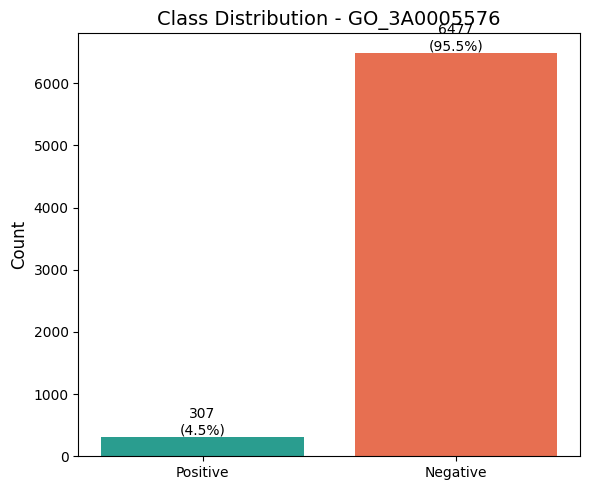

Train: 4748 sequences, 215 positive (4.5%)
Val  : 1018 sequences, 46 positive (4.5%)
Test : 1018 sequences, 46 positive (4.5%)

Model Architecture:
ImprovedCNN1D(
  (embedding): Embedding(21, 128, padding_idx=20)
  (conv1): Sequential(
    (0): Conv1d(128, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(256, eps=1e-05, momen

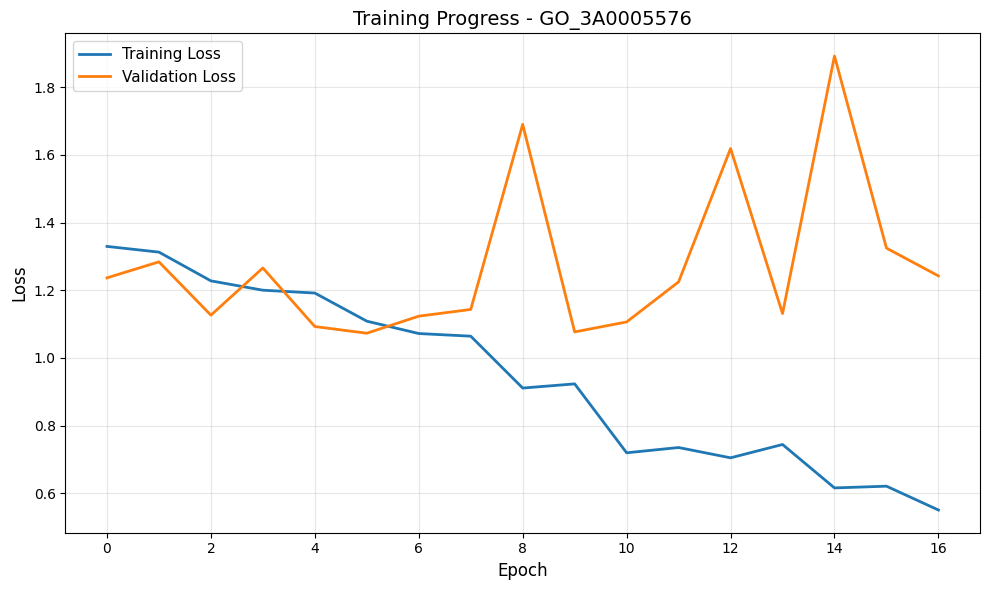


FINAL EVALUATION

Validation Set Evaluation - GO_3A0005576
Accuracy:  0.7692
Precision: 0.1235
Recall:    0.6739
F1 Score:  0.2088
AUC-ROC:   0.7889

Confusion Matrix:
TN:  752  FP:  220
FN:   15  TP:   31

              precision    recall  f1-score   support

    Negative       0.98      0.77      0.86       972
    Positive       0.12      0.67      0.21        46

    accuracy                           0.77      1018
   macro avg       0.55      0.72      0.54      1018
weighted avg       0.94      0.77      0.84      1018


Test Set Evaluation - GO_3A0005576
Accuracy:  0.7741
Precision: 0.1290
Recall:    0.6957
F1 Score:  0.2177
AUC-ROC:   0.7625

Confusion Matrix:
TN:  756  FP:  216
FN:   14  TP:   32

              precision    recall  f1-score   support

    Negative       0.98      0.78      0.87       972
    Positive       0.13      0.70      0.22        46

    accuracy                           0.77      1018
   macro avg       0.56      0.74      0.54      1018
weighted 

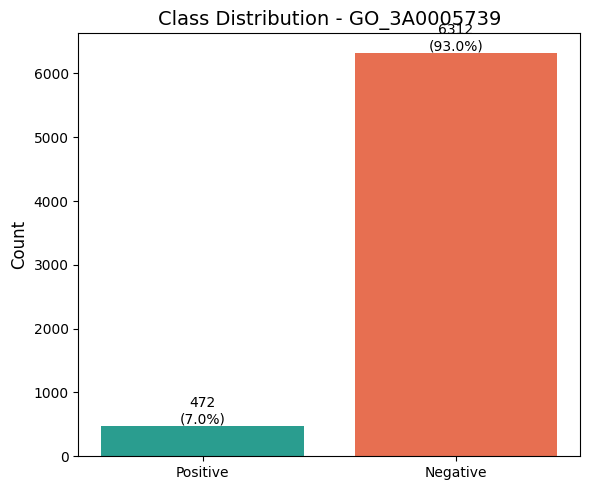

Train: 4748 sequences, 330 positive (7.0%)
Val  : 1018 sequences, 71 positive (7.0%)
Test : 1018 sequences, 71 positive (7.0%)

Model Architecture:
ImprovedCNN1D(
  (embedding): Embedding(21, 128, padding_idx=20)
  (conv1): Sequential(
    (0): Conv1d(128, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(256, eps=1e-05, momen

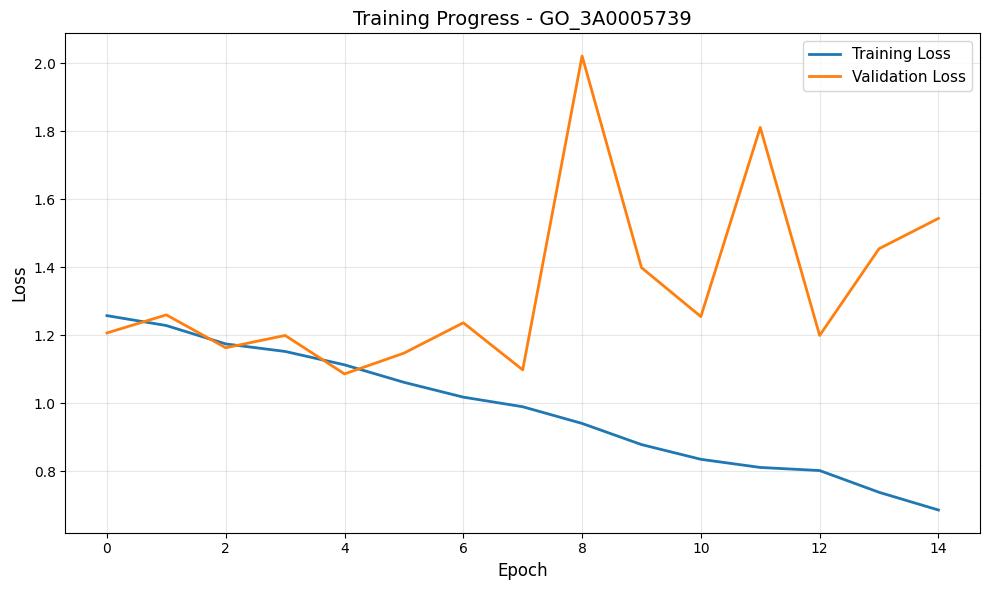


FINAL EVALUATION

Validation Set Evaluation - GO_3A0005739
Accuracy:  0.7505
Precision: 0.1744
Recall:    0.6901
F1 Score:  0.2784
AUC-ROC:   0.7902

Confusion Matrix:
TN:  715  FP:  232
FN:   22  TP:   49

              precision    recall  f1-score   support

    Negative       0.97      0.76      0.85       947
    Positive       0.17      0.69      0.28        71

    accuracy                           0.75      1018
   macro avg       0.57      0.72      0.56      1018
weighted avg       0.91      0.75      0.81      1018


Test Set Evaluation - GO_3A0005739
Accuracy:  0.7682
Precision: 0.1839
Recall:    0.6761
F1 Score:  0.2892
AUC-ROC:   0.7815

Confusion Matrix:
TN:  734  FP:  213
FN:   23  TP:   48

              precision    recall  f1-score   support

    Negative       0.97      0.78      0.86       947
    Positive       0.18      0.68      0.29        71

    accuracy                           0.77      1018
   macro avg       0.58      0.73      0.58      1018
weighted 

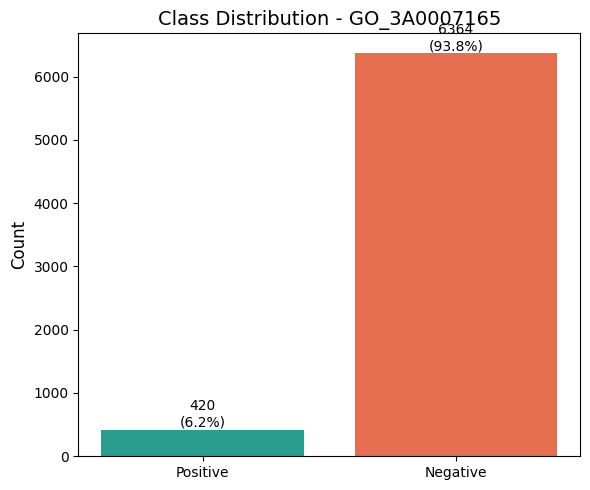

Train: 4748 sequences, 294 positive (6.2%)
Val  : 1018 sequences, 63 positive (6.2%)
Test : 1018 sequences, 63 positive (6.2%)

Model Architecture:
ImprovedCNN1D(
  (embedding): Embedding(21, 128, padding_idx=20)
  (conv1): Sequential(
    (0): Conv1d(128, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(256, eps=1e-05, momen

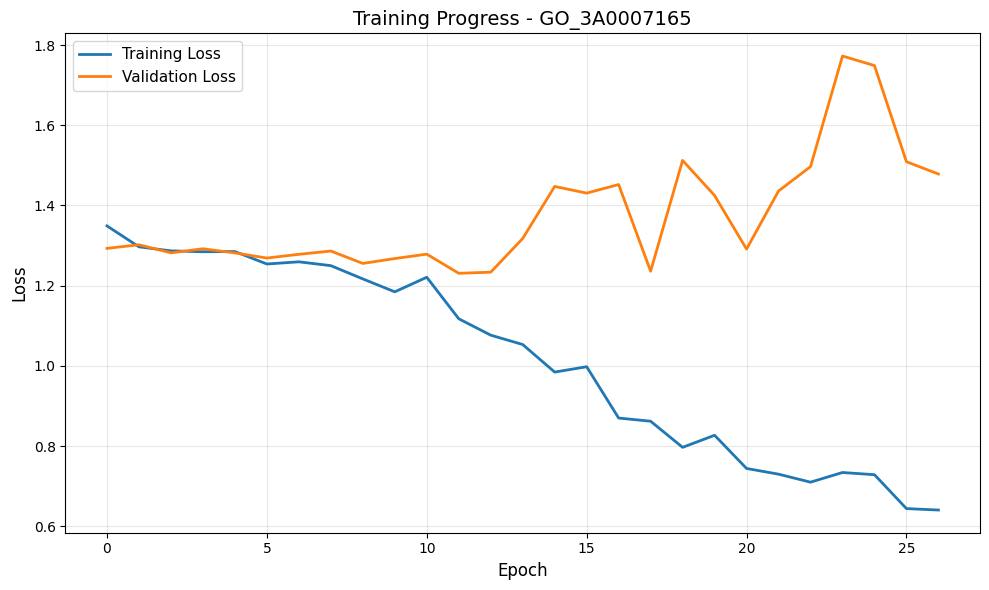


FINAL EVALUATION

Validation Set Evaluation - GO_3A0007165
Accuracy:  0.8880
Precision: 0.2135
Recall:    0.3016
F1 Score:  0.2500
AUC-ROC:   0.6579

Confusion Matrix:
TN:  885  FP:   70
FN:   44  TP:   19

              precision    recall  f1-score   support

    Negative       0.95      0.93      0.94       955
    Positive       0.21      0.30      0.25        63

    accuracy                           0.89      1018
   macro avg       0.58      0.61      0.59      1018
weighted avg       0.91      0.89      0.90      1018


Test Set Evaluation - GO_3A0007165
Accuracy:  0.8674
Precision: 0.0909
Recall:    0.1270
F1 Score:  0.1060
AUC-ROC:   0.5994

Confusion Matrix:
TN:  875  FP:   80
FN:   55  TP:    8

              precision    recall  f1-score   support

    Negative       0.94      0.92      0.93       955
    Positive       0.09      0.13      0.11        63

    accuracy                           0.87      1018
   macro avg       0.52      0.52      0.52      1018
weighted 

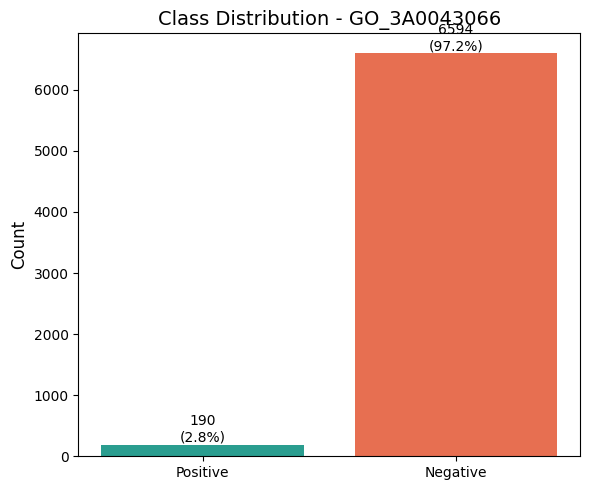

Train: 4748 sequences, 133 positive (2.8%)
Val  : 1018 sequences, 29 positive (2.8%)
Test : 1018 sequences, 28 positive (2.8%)

Model Architecture:
ImprovedCNN1D(
  (embedding): Embedding(21, 128, padding_idx=20)
  (conv1): Sequential(
    (0): Conv1d(128, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(256, eps=1e-05, momen

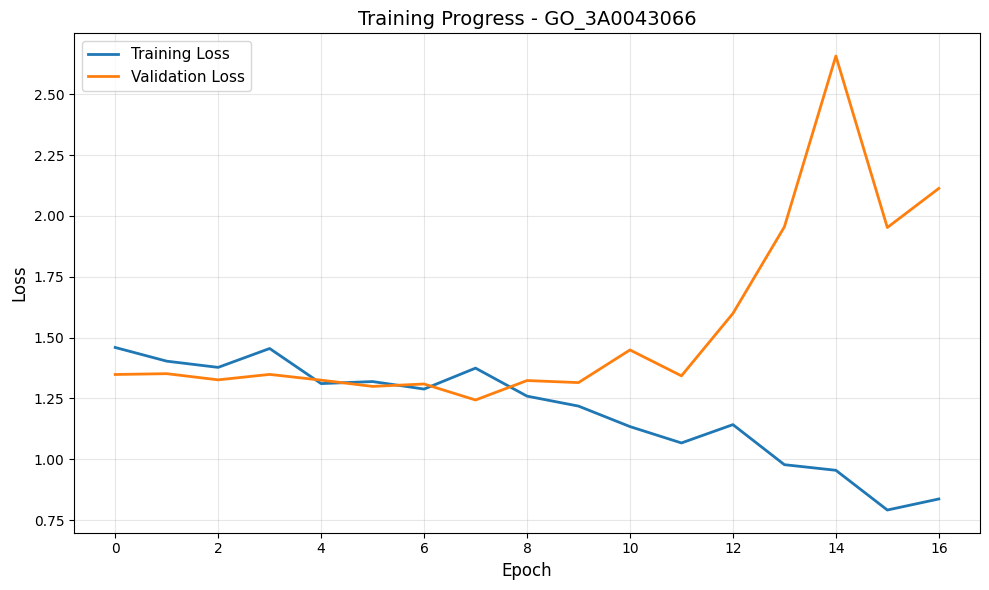


FINAL EVALUATION

Validation Set Evaluation - GO_3A0043066
Accuracy:  0.5039
Precision: 0.0441
Recall:    0.7931
F1 Score:  0.0835
AUC-ROC:   0.6710

Confusion Matrix:
TN:  490  FP:  499
FN:    6  TP:   23

              precision    recall  f1-score   support

    Negative       0.99      0.50      0.66       989
    Positive       0.04      0.79      0.08        29

    accuracy                           0.50      1018
   macro avg       0.52      0.64      0.37      1018
weighted avg       0.96      0.50      0.64      1018


Test Set Evaluation - GO_3A0043066
Accuracy:  0.4479
Precision: 0.0332
Recall:    0.6786
F1 Score:  0.0633
AUC-ROC:   0.6205

Confusion Matrix:
TN:  437  FP:  553
FN:    9  TP:   19

              precision    recall  f1-score   support

    Negative       0.98      0.44      0.61       990
    Positive       0.03      0.68      0.06        28

    accuracy                           0.45      1018
   macro avg       0.51      0.56      0.34      1018
weighted 

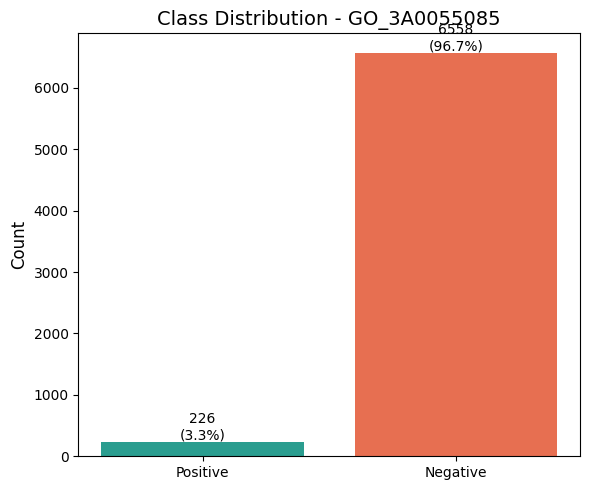

Train: 4748 sequences, 158 positive (3.3%)
Val  : 1018 sequences, 34 positive (3.3%)
Test : 1018 sequences, 34 positive (3.3%)

Model Architecture:
ImprovedCNN1D(
  (embedding): Embedding(21, 128, padding_idx=20)
  (conv1): Sequential(
    (0): Conv1d(128, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(256, eps=1e-05, momen

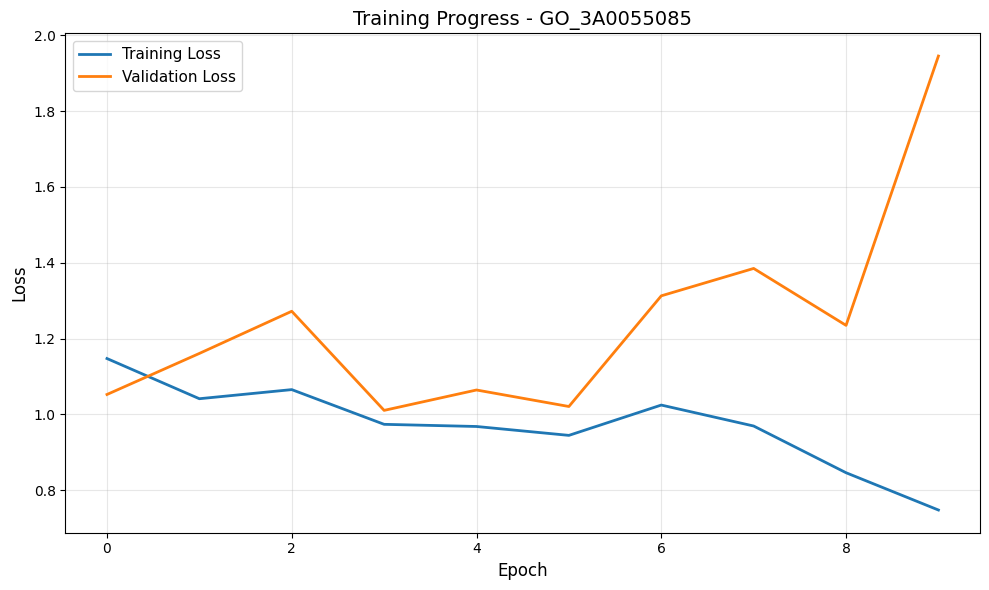


FINAL EVALUATION

Validation Set Evaluation - GO_3A0055085
Accuracy:  0.9715
Precision: 0.6316
Recall:    0.3529
F1 Score:  0.4528
AUC-ROC:   0.8600

Confusion Matrix:
TN:  977  FP:    7
FN:   22  TP:   12

              precision    recall  f1-score   support

    Negative       0.98      0.99      0.99       984
    Positive       0.63      0.35      0.45        34

    accuracy                           0.97      1018
   macro avg       0.80      0.67      0.72      1018
weighted avg       0.97      0.97      0.97      1018


Test Set Evaluation - GO_3A0055085
Accuracy:  0.9764
Precision: 0.7500
Recall:    0.4412
F1 Score:  0.5556
AUC-ROC:   0.8968

Confusion Matrix:
TN:  979  FP:    5
FN:   19  TP:   15

              precision    recall  f1-score   support

    Negative       0.98      0.99      0.99       984
    Positive       0.75      0.44      0.56        34

    accuracy                           0.98      1018
   macro avg       0.87      0.72      0.77      1018
weighted 

GO_3A0005576/learning_rate,██████████▃▃▃▃▁▁▁
GO_3A0005576/test_accuracy,▁
GO_3A0005576/test_auc,▁
GO_3A0005576/test_f1,▁
GO_3A0005576/test_fn,▁
GO_3A0005576/test_fp,▁
GO_3A0005576/test_precision,▁
GO_3A0005576/test_recall,▁
GO_3A0005576/test_tn,▁
GO_3A0005576/test_tp,▁
+121,...



✅ All GO terms processed successfully!
Models saved with pattern: model_GO_*.pt


In [39]:
if __name__ == "__main__":
    # Initialize W&B
    if CONFIG['use_wandb']:
        wandb.init(
            project="protein-go-classification",
            config=CONFIG,
            name=f"multi_go_run_{np.random.randint(1000, 9999)}"
        )

    # Load sequences once
    print("Loading protein sequences...")
    seq_dict = read_human_sequences(CONFIG['seqfile'])
    print(f"Loaded {len(seq_dict)} protein sequences\n")

    # Process all GO terms
    results = []
    for go_file in CONFIG['go_files']:
        if os.path.exists(go_file):
            result = process_go_term(seq_dict, go_file, CONFIG)
            results.append(result)
        else:
            print(f"WARNING: File {go_file} not found, skipping...")

    # Summary
    print(f"\n{'='*80}")
    print("SUMMARY OF ALL GO TERMS")
    print(f"{'='*80}\n")

    summary_data = []
    for result in results:
        go_name = result['go_name']
        metrics = result['test_metrics']
        print(f"{go_name}:")
        print(f"  Test F1:        {metrics['f1']:.4f}")
        print(f"  Test Accuracy:  {metrics['accuracy']:.4f}")
        print(f"  Test Precision: {metrics['precision']:.4f}")
        print(f"  Test Recall:    {metrics['recall']:.4f}")
        print(f"  Test AUC:       {metrics['auc']:.4f}")
        print()

        summary_data.append({
            'GO_Term': go_name,
            'F1': metrics['f1'],
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'AUC': metrics['auc']
        })

    # Create summary table
    if CONFIG['use_wandb']:
        wandb.log({"summary_table": wandb.Table(
            columns=list(summary_data[0].keys()),
            data=[list(d.values()) for d in summary_data]
        )})

    # Finish W&B run
    if CONFIG['use_wandb']:
        wandb.finish()

    print("\n✅ All GO terms processed successfully!")
    print(f"Models saved with pattern: model_GO_*.pt")